# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from impl.utils.explain import vectorize, generate_rules, model_fit, explain, scoring

# Prepare data

In [13]:
from pathlib import Path

projects = [
    "1748884695969-ccea-d240fc", "1748941748026-ccea-b9ac6b", "1748989829337-ccea-4ec741", "1749038770422-ccea-42ed4d",
    "1749777922892-ccea-2c25d2", "1749814642920-ccea-de1f87", "1749886823824-ccea-649444", "1749923655258-ccea-1ba284",
    "1751198102877-ccea-1addfe", "1751208800030-ccea-a4ce3b", "1750185618111-ccea-6e8d47", "1750198943587-ccea-7053fc",
    "1750206690539-ccea-5685b2", "1750216454876-ccea-7d20e2", "1750227193443-ccea-78d6d1", "1750239856908-ccea-022c28",
    "1750251392201-ccea-cf8492", "1750268611439-ccea-719936", "1750277989099-ccea-b24329", "1748920884019-ga-b8096d",
    "1748973401212-ga-159d20", "1749020894373-ga-0c91c0", "1749070990957-ga-e5c457", "1749117177309-ga-e90e3a",
    "1749801622497-ga-1bf740", "1749865564502-ga-d4aeee", "1749911224188-ga-398954", "1749948108048-ga-cf2ad2",
    "1748904187579-rs-eb1239", "1748957118058-rs-2e552d", "1749004788416-rs-6bf5f1", "1749054600895-rs-2ed24b",
    "1749101043616-rs-24f811", "1749789337635-rs-395f0a", "1749825433865-rs-6f42c1", "1749852996207-rs-73049d",
    "1749897744564-rs-122ef9", "1749934847144-rs-a62c00", "1750434085129-ccea-ddb606", "1750449704726-ccea-5b378e",
    "1750463599493-ccea-3174c7", "1750474241344-ccea-de114c", "1750486589729-ccea-d7ee1e", "1750497161663-ccea-e0eee8",
    "1751223236951-ccea-ca103a", "1751231897173-ccea-a652fa", "1751243485332-ccea-36643e", "1751274772053-ccea-ac5042",
    "1750785163861-ccea-21aab6", "1750803393939-ccea-e46291", "1750816760201-ccea-a491e1", "1750840993246-ccea-b56d46",
    "1750864129037-ccea-b6c460", "1750874763838-ccea-c37984", "1751036741158-ccea-8dbdc7", "1751052499693-ccea-37549d",
    "1751064557270-ccea-8d3741", "1751327671761-ccea-fa8901",
]

violations, non_violations = [], []
for project in projects:
    for solution_file in Path("out/results", project, "solutions").rglob("evaluated*"):
        for solution in pickle.loads(solution_file.read_bytes()):
            if solution.is_violated:
                violations.append(solution)
            elif not solution.is_violated and solution.fitness.valid:
                non_violations.append(solution)
if len(non_violations) > len(violations):
    import random

    non_violations = random.sample(non_violations, len(violations))
solutions = violations + non_violations
print(f"#violations: {len(violations)}, #non-violations: {len(non_violations)}, total: {len(solutions)}")

#violations: 597, #non-violations: 443, total: 1040


# Vectorization

In [14]:
X, y, y_v1, y_v2, features = vectorize(solutions, mode="stats")

# Train models

In [ ]:
best_model = model_fit(X, y)

2025-08-06 14:24:53,779     INFO   334100 --- 
RANDOMIZED SEARCH
================================================== (explain.py:110)
2025-08-06 14:24:53,781     INFO   334100 --- Search space size (full grid): 240000, using RandomizedSearchCV with 30 iterations... (explain.py:122)
2025-08-06 14:24:53,782     INFO   334100 --- Starting randomized search... (explain.py:136)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


tostring() is deprecated. Use tobytes() instead.


2025-08-06 14:25:19,180     INFO   334100 --- Randomized search completed! (explain.py:139)
2025-08-06 14:25:19,181     INFO   334100 --- Best CV RMSE: 0.976031 (explain.py:140)
2025-08-06 14:25:19,183     INFO   334100 --- 
Best parameters:
	subsample           : 0.6
	reg_lambda          : 0.5
	reg_alpha           : 0.1
	n_estimators        : 50
	min_child_weight    : 5
	max_depth           : 7
	learning_rate       : 0.05
	colsample_bytree    : 0.7 (explain.py:144)
2025-08-06 14:25:19,184     INFO   334100 --- 
RANDOMIZED SEARCH ANALYSIS
================================================== (explain.py:146)
2025-08-06 14:25:19,200     INFO   334100 --- 
Top 5 parameter combinations:
	1. RMSE: 0.976031 - {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
	2. RMSE: 0.981840 - {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 3, 'max_de

tostring() is deprecated. Use tobytes() instead.


2025-08-06 14:25:19,675     INFO   334100 --- Cross-validation RMSE: 0.976031 (+/- 0.691395) (explain.py:189)
2025-08-06 14:25:19,685     INFO   334100 --- ✓ Best model saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1754504719677/best_model.pkl'. (explain.py:196)
2025-08-06 14:25:19,690     INFO   334100 --- ✓ Randomized search results saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1754504719677/grid_search_results.pkl'. (explain.py:201)
2025-08-06 14:25:19,691     INFO   334100 --- 
MODEL VISUALIZATION
================================================== (explain.py:203)


tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.


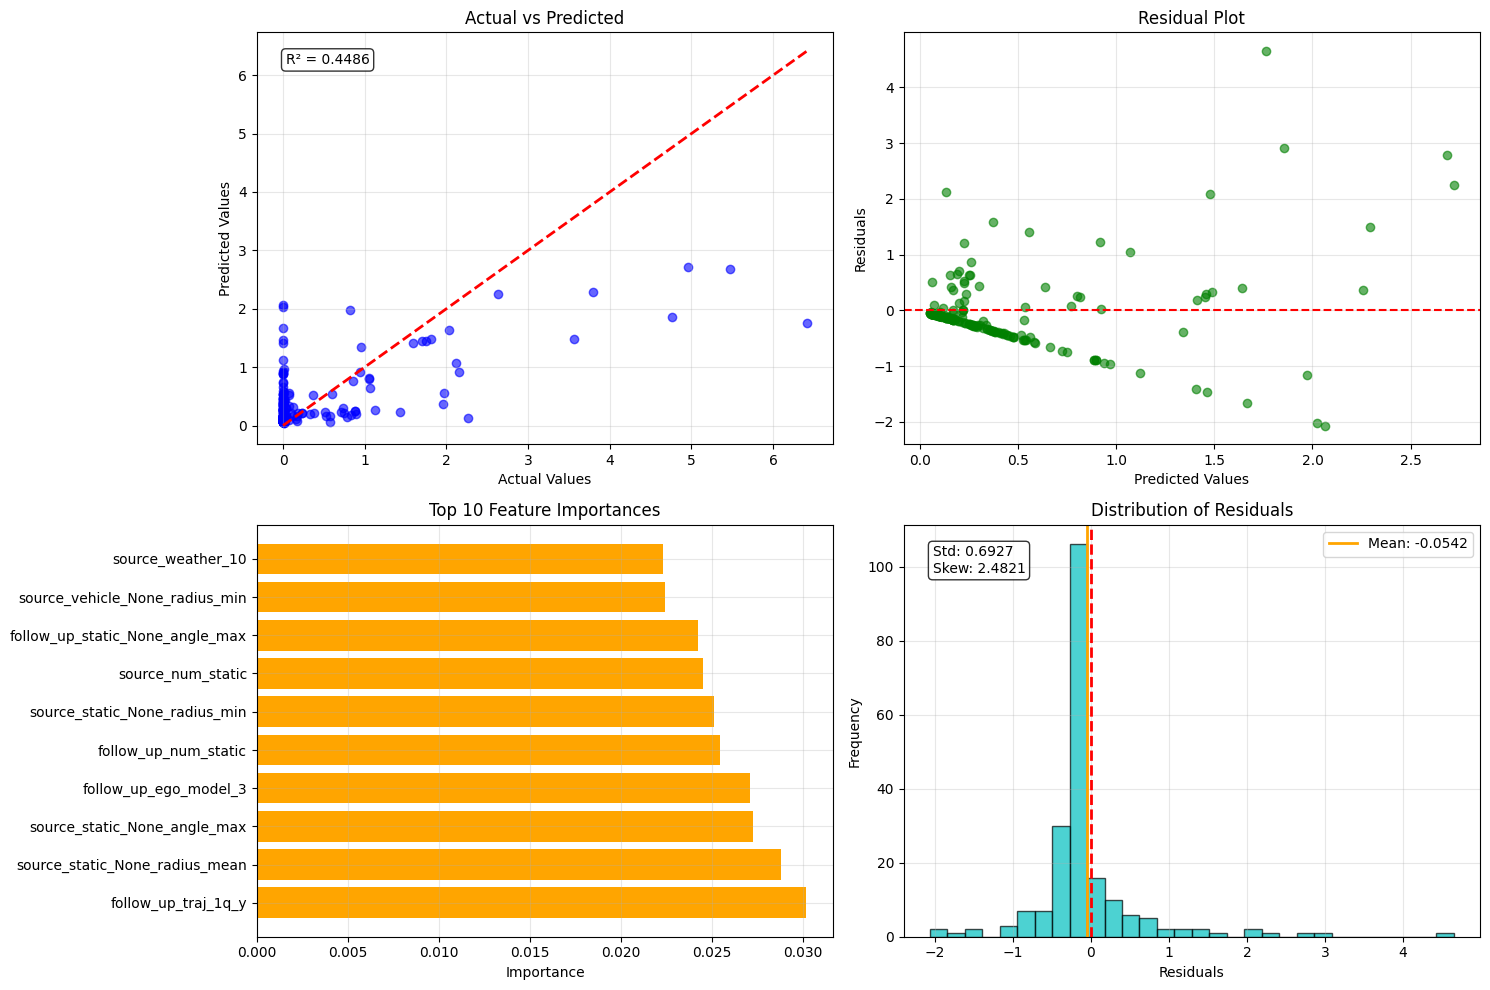

In [12]:
best_model_v1 = model_fit(X, y_v1)

2025-08-06 15:10:36,650     INFO   334100 --- 
RANDOMIZED SEARCH
================================================== (explain.py:110)
2025-08-06 15:10:36,651     INFO   334100 --- Search space size (full grid): 240000, using RandomizedSearchCV with 30 iterations... (explain.py:122)
2025-08-06 15:10:36,652     INFO   334100 --- Starting randomized search... (explain.py:136)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


tostring() is deprecated. Use tobytes() instead.


2025-08-06 15:11:01,767     INFO   334100 --- Randomized search completed! (explain.py:139)
2025-08-06 15:11:01,769     INFO   334100 --- Best CV RMSE: 0.887809 (explain.py:140)
2025-08-06 15:11:01,770     INFO   334100 --- 
Best parameters:
	subsample           : 0.6
	reg_lambda          : 2.0
	reg_alpha           : 1.0
	n_estimators        : 100
	min_child_weight    : 5
	max_depth           : 7
	learning_rate       : 0.01
	colsample_bytree    : 0.8 (explain.py:144)
2025-08-06 15:11:01,771     INFO   334100 --- 
RANDOMIZED SEARCH ANALYSIS
================================================== (explain.py:146)
2025-08-06 15:11:01,775     INFO   334100 --- 
Top 5 parameter combinations:
	1. RMSE: 0.887809 - {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
	2. RMSE: 0.892979 - {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 7, 'max_

tostring() is deprecated. Use tobytes() instead.


2025-08-06 15:11:02,580     INFO   334100 --- Cross-validation RMSE: 0.887809 (+/- 0.543765) (explain.py:189)
2025-08-06 15:11:02,587     INFO   334100 --- ✓ Best model saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1754507462582/best_model.pkl'. (explain.py:196)
2025-08-06 15:11:02,593     INFO   334100 --- ✓ Randomized search results saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1754507462582/grid_search_results.pkl'. (explain.py:201)
2025-08-06 15:11:02,594     INFO   334100 --- 
MODEL VISUALIZATION
================================================== (explain.py:203)


tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.


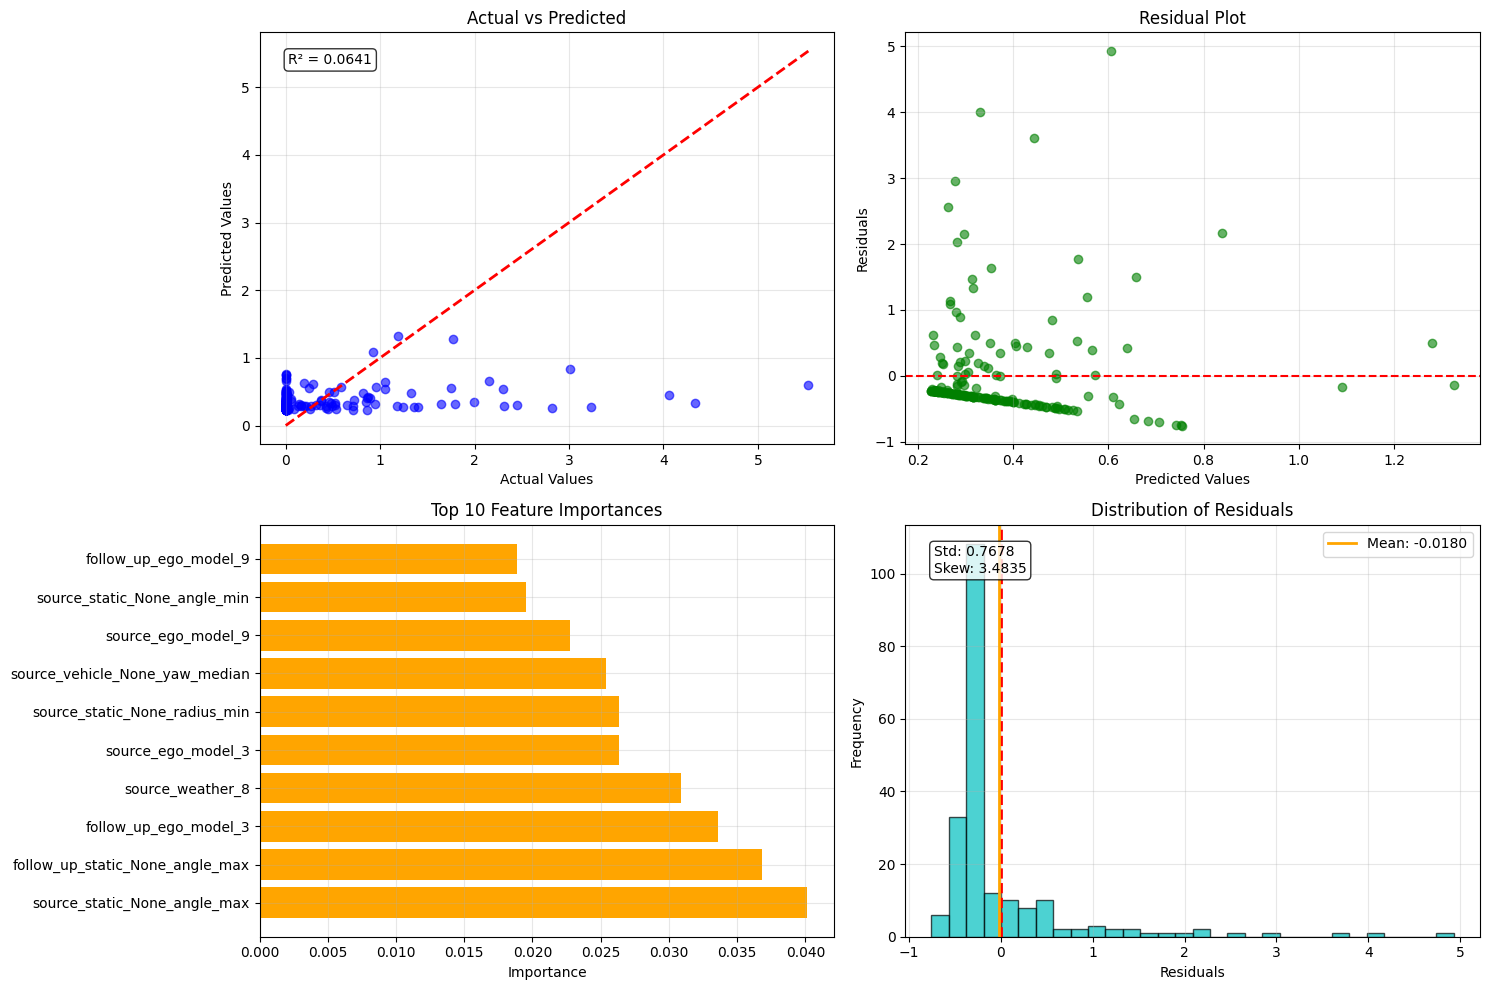

In [14]:
best_model_v2 = model_fit(X, y_v2)

# Load models

In [36]:
import joblib

best_model = joblib.load("out/exp_results/1752513402321/best_model.pkl")
# GBDT
# best_model_v1 = joblib.load("out/exp_results/1751041555795/best_model.pkl")
# best_model_v2 = joblib.load("out/exp_results/1751042068929/best_model.pkl")
# XgBoost
best_model_v1 = joblib.load("out/exp_results/1754504719677/best_model.pkl")
best_model_v2 = joblib.load("out/exp_results/1754507462582/best_model.pkl")

# RuleFit

In [ ]:
rulefit = generate_rules(X, y, features)
rules = rulefit._get_rules()
rules[rules.coef != 0].sort_values("importance", ascending=False).style.background_gradient(cmap="viridis")

# SHAP

In [ ]:
explanation = explain(best_model, X)

# RQ4: MASE comparison

In [15]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy.stats import randint, uniform


def _randomized_search(_X, _y, _model, _param_dist):
    _X_train, _X_test, _y_train, _y_test = train_test_split(_X, np.array(_y), test_size=0.2, random_state=42)
    print("Using RandomizedSearchCV with 100 iterations...")
    _random_search = RandomizedSearchCV(
        estimator=_model(random_state=42),
        param_distributions=_param_dist,
        n_iter=100,
        scoring="r2",
        cv=5,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True,
    )
    print("Starting randomized search...")
    _random_search.fit(_X_train, _y_train)
    print("Randomized search completed!")
    print("Best parameters:")
    for _param, _value in _random_search.best_params_.items():
        print(f"\t{_param:<20}: {_value}")


_randomized_search(X, y, RandomForestRegressor, {
    "n_estimators": randint(100, 301),
    "max_leaf_nodes": randint(3, 11),
    "max_depth": randint(3, 101),
    "min_samples_leaf": randint(1, 11),
    "max_features": uniform(0.1, 0.9),
    "criterion": ["squared_error", "absolute_error"],
})
_randomized_search(X, y, GradientBoostingRegressor, {
    "n_estimators": randint(100, 301),
    "max_leaf_nodes": randint(3, 11),
    "max_depth": randint(3, 101),
    "min_samples_leaf": randint(1, 11),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.6, 0.4),
    "criterion": ["friedman_mse", "squared_error"],
    "loss": ["squared_error", "huber"]
})

Using RandomizedSearchCV with 100 iterations...
Starting randomized search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits


tostring() is deprecated. Use tobytes() instead.


Randomized search completed!
Best parameters:
	criterion           : squared_error
	max_depth           : 35
	max_features        : 0.38522980464064993
	max_leaf_nodes      : 10
	min_samples_leaf    : 2
	n_estimators        : 124
Using RandomizedSearchCV with 100 iterations...
Starting randomized search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits


tostring() is deprecated. Use tobytes() instead.


Randomized search completed!
Best parameters:
	criterion           : squared_error
	learning_rate       : 0.029279593144546104
	loss                : squared_error
	max_depth           : 27
	max_leaf_nodes      : 7
	min_samples_leaf    : 2
	n_estimators        : 227
	subsample           : 0.7221455441377573


In [29]:
from imodels import RuleFitRegressor
from sklearn.metrics import mean_absolute_error

maes = []
for max_rules in (10, 20, 25, 30, 35, 40, 50):
    mae = 0
    iters = 10
    for _ in range(iters):
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
        rulefit = RuleFitRegressor(max_rules=max_rules)
        rulefit.fit(X_train, y_train)
        y_pred_rulefit = rulefit.predict(X_val)
        mae += mean_absolute_error(y_val, y_pred_rulefit)
    maes.append((mae / iters, max_rules))
sorted(maes)

[(0.4374127135786571, 30),
 (0.4407107164116084, 10),
 (0.4458249955595218, 20),
 (0.44605253484886037, 25),
 (0.45434910405492834, 35),
 (0.4596262864425153, 50),
 (0.4639490972803955, 40)]

In [18]:
from collections import defaultdict
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from imodels import RuleFitRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


def _get_leaf_paths(_tree):
    _children_left = _tree.tree_.children_left
    _children_right = _tree.tree_.children_right
    _path_lengths = []

    def _dfs(_node, _depth):
        if _children_left[_node] == -1 and _children_right[_node] == -1:
            _path_lengths.append(_depth)
            return
        if _children_left[_node] != -1:
            _dfs(_children_left[_node], _depth + 1)
        if _children_right[_node] != -1:
            _dfs(_children_right[_node], _depth + 1)

    _dfs(0, 0)
    return _path_lengths


metrics = defaultdict(lambda: defaultdict(list))
for _ in range(500):
    X_train, X_val, y_train, y_val = train_test_split(X, np.array(y), test_size=0.2)

    # Baseline
    y_pred_median = np.full_like(y_val, fill_value=np.median(y_train))
    mae_baseline = mean_absolute_error(y_val, y_pred_median)
    metrics["baseline"]["mae"].append(mae_baseline)

    # RuleFit
    rulefit = RuleFitRegressor(max_rules=30)
    rulefit.fit(X_train, y_train)
    y_pred_rulefit = rulefit.predict(X_val)
    mae_rulefit = mean_absolute_error(y_val, y_pred_rulefit)
    metrics["rulefit"]["mae"].append(mae_rulefit)
    metrics["rulefit"]["mase"].append(mae_rulefit / mae_baseline)
    rules = rulefit._get_rules()
    rules = rules[rules.coef != 0]
    metrics["rulefit"]["rule"].append(rules)
    feature_counts = []
    for _, row in rules.iterrows():
        if row["rule"] == "linear": feature_counts.append(1)
        feature_counts.append(len(row["rule"].split("and")))
    metrics["rulefit"]["size"].append(len(rules))
    metrics["rulefit"]["length"].append(feature_counts)

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=124,
        max_depth=35,
        max_leaf_nodes=10,
        min_samples_leaf=2,
        max_features=0.38522980464064993,
        criterion="squared_error",
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_val)
    mae_rf = mean_absolute_error(y_val, y_pred_rf)
    metrics["rf"]["mae"].append(mae_rf)
    metrics["rf"]["mase"].append(mae_rf / mae_baseline)
    n_leaves_rf = sum(est.tree_.n_leaves for est in rf.estimators_)
    metrics["rf"]["size"].append(n_leaves_rf)
    path_lengths_rf = [length for est in rf.estimators_ for length in _get_leaf_paths(est)]
    metrics["rf"]["length"].append(path_lengths_rf)
    assert n_leaves_rf == len(path_lengths_rf)

    # GBDT
    gbdt = GradientBoostingRegressor(
        n_estimators=227,
        max_depth=27,
        max_leaf_nodes=7,
        min_samples_leaf=2,
        subsample=0.7221455441377573,
        learning_rate=0.029279593144546104,
        criterion="squared_error",
        loss="squared_error",
    )
    gbdt.fit(X_train, y_train)
    y_pred_gbdt = gbdt.predict(X_val)
    mae_gbdt = mean_absolute_error(y_val, y_pred_gbdt)
    metrics["gbdt"]["mae"].append(mae_gbdt)
    metrics["gbdt"]["mase"].append(mae_gbdt / mae_baseline)
    n_leaves_gbdt = sum(est[0].tree_.n_leaves for est in gbdt.estimators_)
    metrics["gbdt"]["size"].append(n_leaves_gbdt)
    path_lengths_gbdt = [length for est in gbdt.estimators_ for length in _get_leaf_paths(est[0])]
    metrics["gbdt"]["length"].append(path_lengths_gbdt)
    assert n_leaves_gbdt == len(path_lengths_gbdt)

with open("out/mase.pkl", "wb") as f:
    pickle.dump(dict(metrics), f)

In [2]:
with open("out/mase.pkl", "rb") as f:
    metrics = pickle.load(f)

========== RuleFit ==========
Avg. MAE:			0.4508930182629265
Avg. #rules:		28.71
Avg. rule length:	2.27
========== RF ==========
Avg. MAE:			0.40772511843110837
Avg. #rules:		1240.00
Avg. rule length:	3.93
========== GBDT ==========
Avg. MAE:			0.43551935857244234
Avg. #rules:		1589.00
Avg. rule length:	3.20


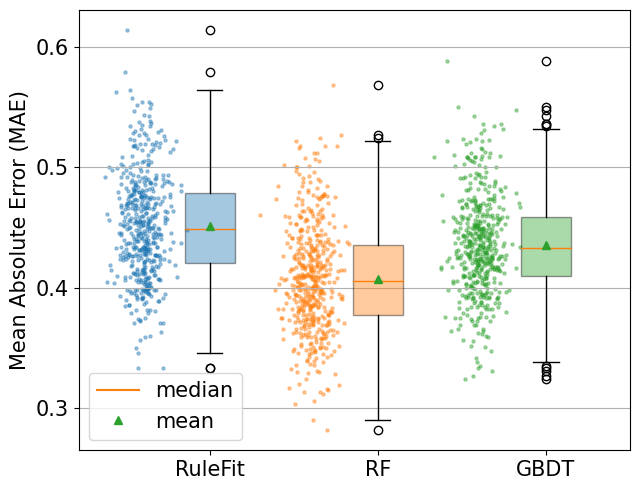

In [7]:
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

height = 5
text_size, tick_size = height * 3, height * 3
fig, ax = plt.subplots(figsize=(height * 1.3, height))
labels = ["RuleFit", "RF", "GBDT"]
values = [metrics[alg.lower()]["mae"] for alg in labels]
for alg in labels:
    print(f"========== {alg} ==========")
    print(f"Avg. MAE:\t\t\t{np.mean(metrics[alg.lower()]['mae'])}")
    print(f"Avg. #rules:\t\t{np.mean(metrics[alg.lower()]['size']):.2f}")
    print(f"Avg. rule length:\t{np.mean([np.mean(lengths) for lengths in metrics[alg.lower()]['length']]):.2f}")
bplot = ax.boxplot(values, labels=labels, showmeans=True, patch_artist=True)
for patch, color in zip(bplot["boxes"], [f"C{i}" for i in range(10)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
for i, value in enumerate(values):
    ax.scatter(np.random.normal(i + 0.6, 0.08, len(value)), value, alpha=0.4, s=5)
ax.grid(axis="y")
ax.tick_params(labelsize=tick_size)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_ylabel("Mean Absolute Error (MAE)", fontsize=text_size)
ax.legend(handles=[
    Line2D([0], [0], c="C1", label="median"),
    Line2D([0], [0], ls="None", marker="^", mfc="C2", mec="C2", label="mean")
], fontsize=text_size)
plt.tight_layout()
plt.savefig("out/visualizations/mae.pdf")

# RQ4: Support for the rules

In [32]:
ny = np.array(y)
X_vio = X[ny != 0]
support = []
for rule_df in metrics["rulefit"]["rule"]:
    non_linear_rules = rule_df[rule_df.type != "linear"]
    unique = set()
    for i, row in non_linear_rules.iterrows():
        rule = row["rule"]
        satisfied = X_vio.query(rule)
        unique |= set(satisfied.index)
    support.append(len(unique) / len(X_vio))

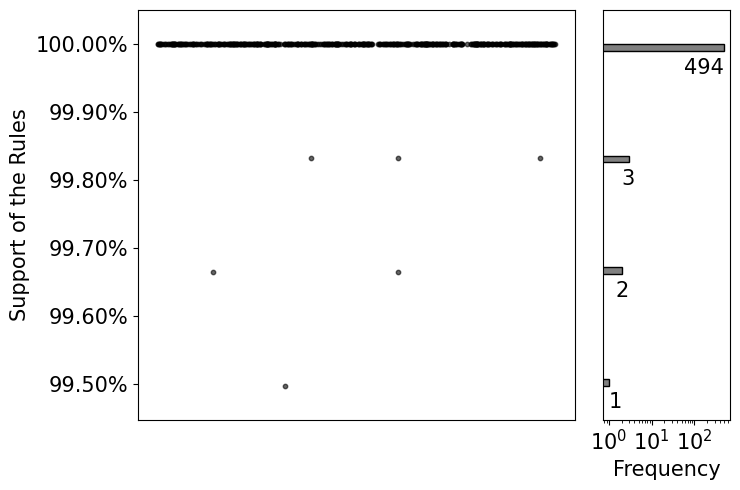

In [33]:
from matplotlib.ticker import PercentFormatter

data_x = np.random.rand(len(support))
data_y = np.array(support)
y_min = np.min(data_y)
y_max = np.max(data_y)

height = 5
text_size, tick_size = height * 3, height * 3
fig = plt.figure(figsize=(height * 1.5, height))
ax_scatter = plt.subplot2grid((4, 4), (0, 0), colspan=3, rowspan=4)
ax_hist_y = plt.subplot2grid((4, 4), (0, 3), rowspan=4)

ax_scatter.scatter(data_x, data_y, c="k", marker="o", s=10, alpha=0.6)
ax_scatter.set_ylabel("Support of the Rules", fontsize=text_size)
padding = 0.0005
ax_scatter.set_ylim(y_min - padding, y_max + padding)
ax_scatter.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_scatter.set_xticks([])
ax_scatter.tick_params(labelsize=tick_size)

hist, bin_edges, _ = ax_hist_y.hist(data_y, bins=np.linspace(y_min, y_max, 50),
                                    orientation="horizontal", log=True,
                                    color="gray", edgecolor="black")
ax_hist_y.set_ylim(y_min - padding, y_max + padding)
ax_hist_y.set_yticks([])
ax_hist_y.tick_params(labelsize=tick_size)
for i, (count, bin_edge) in enumerate(zip(hist, bin_edges[:-1])):
    if count > 0:
        ax_hist_y.text(count + 1, bin_edge - 0.0001, f"{int(count)}", c="black",
                       va="top", ha="right", fontsize=tick_size)
ax_hist_y.set_xlabel("Frequency", fontsize=text_size)
plt.tight_layout()
plt.savefig("out/visualizations/support.pdf")

# RQ4: Consistency of importance

In [ ]:
score, D, W = scoring(best_model_v1, best_model_v2, X)
score

In [38]:
feature_importance = abs(W * D).mean(axis=0)
shap_rank = (pd.DataFrame({"feature": features, "importance": feature_importance})
             .sort_values("importance", ascending=False))
top_k_overlaps = []
for top_k in range(1, 31):
    overlaps = []
    for rule_df in metrics["rulefit"]["rule"]:
        rulefit_rank = rule_df[rule_df.type != "linear"].sort_values("importance", ascending=False).reset_index()
        rank = []
        for _, row in shap_rank.head(top_k).iterrows():
            rank.append(rulefit_rank["rule"].str.contains(row["feature"]).idxmax() + 1)
        overlaps.append(sum(1 for r in rank if r <= top_k) / top_k)
    top_k_overlaps.append(overlaps)

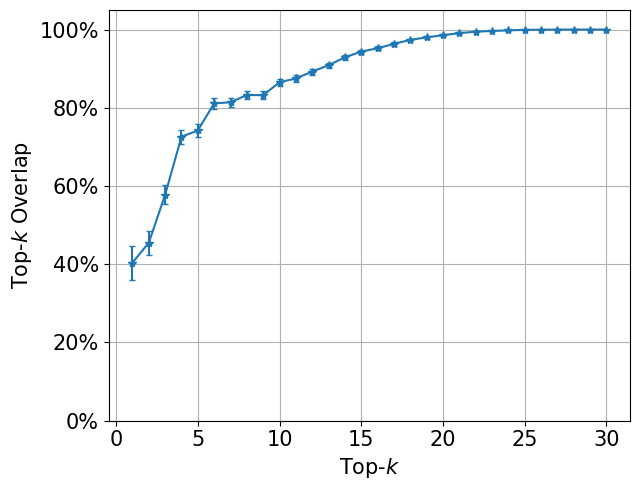

In [74]:
height = 5
text_size, tick_size = height * 3, height * 3
fig, ax = plt.subplots(figsize=(height * 1.3, height))
ax.errorbar(np.arange(1, 31), np.mean(top_k_overlaps, axis=1),
            yerr=1.96 * np.std(top_k_overlaps, axis=1, ddof=1) / np.sqrt(len(top_k_overlaps[0])),
            fmt="*-C0", capsize=2)
ax.grid()
ax.set_xlabel("Top-$k$", fontsize=text_size)
ax.set_ylabel("Top-$k$ Overlap", fontsize=text_size)
ax.tick_params(labelsize=tick_size)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig("out/visualizations/top_k_overlap.pdf")

# Most important rules and features

In [ ]:
pd.concat(metrics["rulefit"]["rule"]).sort_values("importance", ascending=False)

In [ ]:
pd.DataFrame({"feature": features, "importance": abs(W * D).mean(axis=0)}).sort_values("importance", ascending=False)

# RAD comparison

In [7]:
def _evaluate_rules(_rules, _X, _y):
    _y = np.array(_y)
    for _i, _row in _rules[(_rules.coef != 0) & (_rules.type != "linear")].iterrows():
        _rule = _row["rule"]
        _rulefit_mask = np.zeros(_y.size, dtype=bool)
        _rulefit_mask[_X.query(_rule).index] = True
        _rulefit_diff = _y[_rulefit_mask].mean() - _y[~_rulefit_mask].mean()
        _rulefit_score = np.sign(_rulefit_diff * _row["coef"]) * np.abs(_rulefit_diff - _row["coef"])
        rules.loc[_i, "score_rulefit"] = _rulefit_score
        rules.loc[_i, "diff_rulefit"] = _rulefit_diff

        _n = len(_y)
        _base_mask = np.array([True] * (_n // 2) + [False] * (_n - _n // 2))
        _rand_diff = 0
        _times = 1000
        for _ in range(_times):
            _rand_mask = np.random.permutation(_base_mask)
            _rand_diff += _y[_rand_mask].mean() - _y[~_rand_mask].mean()
        _rand_diff /= _times
        _rand_score = np.sign(_rand_diff * _row["coef"]) * np.abs(_rand_diff - _row["coef"])
        rules.loc[_i, "score_random"] = _rand_score
        rules.loc[_i, "diff_random"] = _rand_diff

In [51]:
dfs = []
for _ in range(500):
    rulefit = generate_rules(X, y, features)
    rules = rulefit._get_rules()
    _evaluate_rules(rules, X, y)
    dfs.append(rules)
df = pd.concat(dfs)
df = df[(df.coef != 0) & (df.type != "linear")]

with open("out/rad.pkl", "wb") as f:
    pickle.dump(df, f)

In [8]:
with open("out/rad.pkl", "rb") as f:
    df = pickle.load(f)

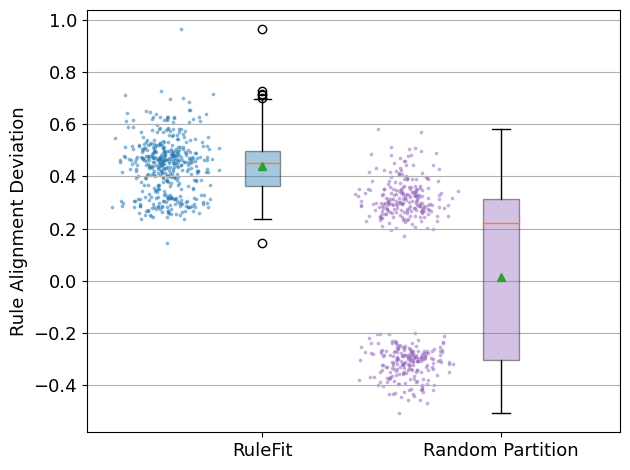

In [9]:
fig, ax = plt.subplots()
sorted_df = df.sort_values("importance", ascending=False).head(len(df) // 10)
values = [sorted_df["score_rulefit"], sorted_df["score_random"]]
bplot = ax.boxplot(values, labels=["RuleFit", "Random Partition"], showmeans=True, patch_artist=True)
for patch, color in zip(bplot["boxes"], ("C0", "C4")):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
for i, (value, color) in enumerate(zip(values, ("C0", "C4"))):
    ax.scatter(np.random.normal(i + 0.6, 0.08, len(value)), value, color=color, alpha=0.4, s=3)
ax.grid(axis="y")
ax.tick_params(labelsize=13)
ax.set_ylabel("Rule Alignment Deviation", fontsize=13)
plt.tight_layout()
plt.savefig("out/visualizations/rcd.png")